# <font color="black">**Assignment - 1: Auditing and Exploiting Low-Rank Approximation's Assumptions**</font>


### **Course: Foundation of Large Language Models (AI60213)**
### <font color="red">**Due date: September-17-2026**</font>

## Advisory

<font color="red"><b>Using generative AI tools to complete the assignment is discouraged, as it increases the probability of plagiarism with others who may choose the same approach. If Generative AI tools were used, please briefly mention the purpose and the relevant parts of the assignment where they were used.</b></font>

## Compute Requirements

1. One mid-range GPU (T-4) is sufficient for all experiments.
2. A small encoder model, BERT-base, must be used to ensure consistency.

## Submission Instructions

1. Only one member from each group needs to submit the assignment through Moodle to avoid any duplicate submissions.
2. Submit the Solution file as: **`Group(number)_assignment_1_solution.ipynb`** and a **`Group(number)_assignment_1_solution.py`** file as well.

## Plagiarism Policy

1. Code plagiarism will be checked on the designated blocks which the students have to code.
2. No penalty till 30% (Baseline).
3. Each 10% increase over baseline will cost 1 mark, Beyond 70% absolute-2 (negative).
4. Two groups having similar code will be penalized with the same amount. No arbitration will be done.
5. Late submission policy: One week window with a penalty of 3 marks.

## Setup Instructions

1. Pick a small pretrained model, such as **BERT-base**.
2. Pick a GLUE-style <font color="red">([https://huggingface.co/datasets/nyu-mll/glue/](https://huggingface.co/datasets/nyu-mll/glue/))</font> classification task, such as **MRPC** (two-class sentence equivalence, small, 6k samples) and **SST-2** (two-class sentiment, medium, 70k samples).
3. This assignment rewards depth of analysis.

In [1]:
## ------Start-----##
from datasets import load_dataset

mrpc = load_dataset("nyu-mll/glue", "mrpc")
sst2 = load_dataset("nyu-mll/glue", "sst2")

/home/shivraj-pg/miniconda3/envs/assign1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
mrpc.unique('label')

{'train': [1, 0], 'validation': [1, 0], 'test': [1, 0]}

In [3]:
print(mrpc)

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})


In [4]:
sst2.unique('label')

{'train': [0, 1], 'validation': [1, 0], 'test': [-1]}

NOTE FOR EVALUATOR: SINCE I DONT HAVE LABELS FOR TEST HERE I AM MERGING THE ENTIRE DTA TRAIN+VALIDATION AND SPLITTING IN 90:5:5 ratio for further tasks

In [5]:
from datasets import concatenate_datasets, DatasetDict

In [6]:
sst2 = concatenate_datasets([sst2["train"], sst2["validation"]])
sst2 = sst2.shuffle(seed=42)

In [7]:
split1 = sst2.train_test_split(test_size=0.10,seed=42)
split2 = split1["test"].train_test_split(test_size=0.50, seed=42)

sst2 = DatasetDict(
    {
    "train": split1["train"],
    "validation": split2["train"],
    "test": split2["test"]
})

print(sst2)

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 61398
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 3411
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 3412
    })
})


In [8]:
mrpc.save_to_disk("Dataset/mrpc")
sst2.save_to_disk("Dataset/sst2")

Saving the dataset (1/1 shards): 100%|██████████| 3412/3412 [00:00<00:00, 251909.26 examples/s]


In [9]:
print(sst2)
print(mrpc)

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 61398
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 3411
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 3412
    })
})
DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})


## <font color="blue"><b>Part-1: Empirically Audit the Low-Rank Approximation Hypothesis.</b></font>


LoRA rests on the claim that the weight update

$$
\Delta W = W_{\text{finetuned}} - W_{\text{pretrained}}
$$

has low intrinsic rank. Empirically test this claim using **BERT-base**.
_________

###<font color="purple">**Part 1.1 Full Fine-Tuning — 1 mark**</font>
Fully fine-tune BERT-base on two tasks:
- Sentiment classification
- Sentence equivalence classification

Use standard full fine-tuning (**no LoRA**) and save both checkpoints.
_______________

### <font color="green">**Part 1.2. Compute Weight Updates — 1 mark**</font>
For **every Q, K, V, O projection and FFN matrix across all layers**, compute:

$$
\Delta W_\ell =
W_\ell^{(\text{finetuned})} -
W_\ell^{(\text{pretrained})}.
$$
_________

### <font color="purple">**Part 1.3. SVD and Effective Rank — 2 marks**</font>
For every $\Delta W_\ell$, compute its singular values using SVD and determine the smallest $k$ for which the top-$k$ singular values capture:

- **90%** of the Frobenius norm
- **99%** of the Frobenius norm
___________

### <font color="green">**Part 1.4. Plots and Two-Task Comparison — 3 marks**</font>

For **each task**, produce:

1. **Effective Rank vs. Layer Depth**
   - X-axis: Layer depth
   - Y-axis: Effective rank
   - Show both **90% and 99%** ranks
   - Distinguish **Q, K, V, O, and FFN**

2. **Effective Rank vs. Matrix Type**
   - X-axis: Matrix type (**Q, K, V, O, FFN**)
   - Y-axis: Effective rank
   - Show both **90% and 99%** ranks
   - Preserve layer-wise results; do not report only a single average.

3. **Per-Matrix Heatmap**
   - X-axis: Matrix type
   - Y-axis: Layer depth
   - Cell value: Effective rank
   - Provide separate **90% and 99%** heatmaps.

4. **Cross-Task Comparison**
   - Overlay the **rank-vs-depth** profiles of both tasks.
   - Compare **rank-by-matrix-type** across both tasks.
   - Use the same axes/scales for direct comparison.

5. **Full Per-Matrix Table**
   - Report **Task, Layer, Matrix Type, 90% Rank, and 99% Rank** for every matrix.
   - **No averaging or omission of individual matrices.**
___________________________

<font color="red"><b><i>Note:</i></b> Complete the coding only in the designated sections marked <b><code>## Code Here ##</code></b> and complete the reflections/answers only in the designated sections marked <b><code>## ANSWER HERE ##</code></b>. Do not modify the provided code or questions outside these sections unless explicitly instructed. Ensure that all implementations, required outputs, plots, reflections, and analyses are complete and address the requirements of each question.</font>

In [10]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import defaultdict
from torch.utils.data import TensorDataset, DataLoader
from datasets import load_dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup
import os
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)

In [11]:
MODEL_NAME = "bert-base-uncased"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MAX_LEN, BATCH_SIZE, EPOCHS, LR = 128, 64, 2, 2e-5

# GLUE task - datasets.
TASK_FIELDS = {
    "sst2": ("sentence", None),
    "mrpc": ("sentence1", "sentence2"),
}
MATRIX_ORDER = ["Q", "K", "V", "O", "FFN_in", "FFN_out"]

_______________
Tokenize via `datasets.map(batched=True)` (avoids the datasets-5.x lazy Column bug); convert to tensors once with explicit dtype=torch.long. Handles both single-sentence (SST-2) and sentence-pair (MRPC) tasks.
_______________

In [12]:
def build_loaders(task, tokenizer):

    if task == "sst2":
        dataset = sst2

    elif task == "mrpc":
        dataset = mrpc

    else:
        print("Wrong task")
        return None, None

    field1, field2 = TASK_FIELDS[task]

    def tokenize_batch(batch):

        if field2 is None:
            return tokenizer(
                batch[field1],
                padding="max_length",
                truncation=True,
                max_length=MAX_LEN
            )

        else:
            return tokenizer(
                batch[field1],
                batch[field2],
                padding="max_length",
                truncation=True,
                max_length=MAX_LEN
            )

    dataset = dataset.map(
        tokenize_batch,
        batched=True
    )

    train_input_ids = torch.tensor(
        dataset["train"]["input_ids"],
        dtype=torch.long
    )

    train_attention_mask = torch.tensor(
        dataset["train"]["attention_mask"],
        dtype=torch.long
    )

    train_labels = torch.tensor(
        dataset["train"]["label"],
        dtype=torch.long
    )

    val_input_ids = torch.tensor(
        dataset["validation"]["input_ids"],
        dtype=torch.long
    )

    val_attention_mask = torch.tensor(
        dataset["validation"]["attention_mask"],
        dtype=torch.long
    )

    val_labels = torch.tensor(
        dataset["validation"]["label"],
        dtype=torch.long
    )

    train_dataset = TensorDataset(
        train_input_ids,
        train_attention_mask,
        train_labels
    )

    val_dataset = TensorDataset(
        val_input_ids,
        val_attention_mask,
        val_labels
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    return train_loader, val_loader

_________
Snapshot only 2D encoder-layer weights (Q/K/V/O + FFN). Embeddings -> Part C; classifier head is random-init, so its "delta" is excluded.
___________

In [13]:
def linear_weight_snapshot(model):

    snapshot = {}

    for name, param in model.named_parameters():
        if not name.endswith(".weight"):
            continue
        if param.ndim != 2:
            continue
        
        if "encoder.layer" not in name:
            continue

        snapshot[name] = param.detach().cpu().clone()

    return snapshot

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct = total = 0
    loss_sum = 0.0
    for input_ids, attn_mask, labels in loader:
        input_ids, attn_mask, labels = input_ids.to(DEVICE), attn_mask.to(DEVICE), labels.to(DEVICE)
        out = model(input_ids=input_ids, attention_mask=attn_mask, labels=labels)
        loss_sum += out.loss.item() * labels.size(0)
        correct  += (out.logits.argmax(-1) == labels).sum().item()
        total    += labels.size(0)
    return correct / total, loss_sum / total

_________
effective rank: smallest k s.t. top-k singular values capture `energy`
fraction of the Frobenius norm.  ||dW||_F^2 = sum(sigma_i^2)  ->  threshold
on cumulative SQUARED singular values.
_________

In [14]:
def effective_rank(delta, energy):

    sigmas = torch.linalg.svdvals(delta)

    total_energy = torch.sum(sigmas ** 2).item()

    if total_energy == 0:
        return 0

    cumulative_energy = 0.0

    for i in range(len(sigmas)):
        cumulative_energy += sigmas[i].item() ** 2
        fraction = cumulative_energy / total_energy
        if fraction >= energy:
            return i + 1
        
    k = len(sigmas)

    return k

def classify_matrix(name):
    if "attention.self.query"   in name: return "Q"
    if "attention.self.key"     in name: return "K"
    if "attention.self.value"   in name: return "V"
    if "attention.output.dense" in name: return "O"
    if "intermediate.dense"     in name: return "FFN_in"
    if "output.dense"           in name: return "FFN_out"
    return "other"

_____________
full fine-tune then audit EVERY matrix. One record per matrix
(layer, mtype, k90, k99, dim) -> nothing is averaged away at this stage.
_____________

In [15]:
def finetune_and_audit(task):
    print(f"\n########## TASK: {task} ##########")
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(DEVICE)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    pretrained = linear_weight_snapshot(model)                 # BEFORE training
    train_loader, val_loader = build_loaders(task, tokenizer)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, int(0.06 * total_steps), total_steps)

    for epoch in range(1, EPOCHS + 1):
        ## CODE HERE ##
        model.train()
        running = 0
        
        for step, (input_id, attn_mask, labels) in enumerate(train_loader, start=1):
            
            input_id = input_id.to(DEVICE)
            attn_mask = attn_mask.to(DEVICE)
            labels = labels.to(DEVICE)
            
            optimizer.zero_grad()
            
            out = model(input_ids=input_id, attention_mask=attn_mask, labels=labels)
            
            loss=out.loss
            loss.backward()
            
            optimizer.step()
            scheduler.step()
            
            running += loss.item()
        
            if step % 200 == 0:
                print(f"  epoch {epoch} step {step}/{len(train_loader)}  loss {running/200:.4f}")
                running = 0.0
        acc, loss = evaluate(model, val_loader)
        print(f"  [epoch {epoch}] val_acc={acc:.4f}  val_loss={loss:.4f}")

    acc, _ = evaluate(model, val_loader)
    print(f"  FINAL {task} val accuracy: {acc:.4f}")
    
    save_dir = f"./Output/ft_{task}"
    os.makedirs(save_dir, exist_ok=True)
    model.save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)

    finetuned = linear_weight_snapshot(model)
    rows = []
    ## CODE HERE ##
    
    for matrix in pretrained:
        delta = finetuned[matrix] - pretrained[matrix]
        
        k90 = effective_rank(delta, 0.90)
        k99 = effective_rank(delta, 0.99)
        
        mtype = classify_matrix(matrix)
        
        rows.append({
            "layer": int(matrix.split(".")[3]),
            "mtype": mtype,
            "k90": k90,
            "k99": k99,
            "dim": tuple(delta.shape)
            })
        
    return rows

In [16]:
rows_sst2 = finetune_and_audit("sst2")


########## TASK: sst2 ##########


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7424.60it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

  epoch 1 step 200/960  loss 0.4228
  epoch 1 step 400/960  loss 0.2195
  epoch 1 step 600/960  loss 0.2085
  epoch 1 step 800/960  loss 0.1840
  [epoch 1] val_acc=0.9440  val_loss=0.1493
  epoch 2 step 200/960  loss 0.1141
  epoch 2 step 400/960  loss 0.1084
  epoch 2 step 600/960  loss 0.1162
  epoch 2 step 800/960  loss 0.1090
  [epoch 2] val_acc=0.9525  val_loss=0.1381
  FINAL sst2 val accuracy: 0.9525


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.73it/s]


In [17]:
rows_mrpc = finetune_and_audit("mrpc")
ALL_TASKS = [("SST-2", rows_sst2), ("MRPC", rows_mrpc)]


########## TASK: mrpc ##########


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6080.07it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

  [epoch 1] val_acc=0.7059  val_loss=0.5590
  [epoch 2] val_acc=0.7672  val_loss=0.4872
  FINAL mrpc val accuracy: 0.7672


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.18it/s]


In [18]:
# =============================================================================
# FULL per-matrix table — one row per matrix, NO averaging.
# Raw evidence (72 rows for BERT-base: 12 layers x 6 types). Run for BOTH tasks.
# =============================================================================
import pandas as pd
def per_matrix_table(rows, task):
    ## CODE HERE ##
    
    df = pd.DataFrame(rows)

    print(f"{task} — PER-MATRIX EFFECTIVE RANKS")

    print(df.to_string(index=False))

    print(f"\nNumber of matrices: {len(df)}")

for task, rows in ALL_TASKS:
    per_matrix_table(rows, task)

SST-2 — PER-MATRIX EFFECTIVE RANKS
 layer   mtype  k90  k99         dim
     0       Q  234  481  (768, 768)
     0       K  235  483  (768, 768)
     0       V  204  460  (768, 768)
     0       O  214  471  (768, 768)
     0  FFN_in  441  696 (3072, 768)
     0 FFN_out  408  692 (768, 3072)
     1       Q  215  463  (768, 768)
     1       K  223  473  (768, 768)
     1       V  186  443  (768, 768)
     1       O  197  452  (768, 768)
     1  FFN_in  428  690 (3072, 768)
     1 FFN_out  399  688 (768, 3072)
     2       Q  202  446  (768, 768)
     2       K  211  461  (768, 768)
     2       V  203  455  (768, 768)
     2       O  199  453  (768, 768)
     2  FFN_in  412  686 (3072, 768)
     2 FFN_out  384  683 (768, 3072)
     3       Q  213  464  (768, 768)
     3       K  225  477  (768, 768)
     3       V  200  452  (768, 768)
     3       O  203  458  (768, 768)
     3  FFN_in  411  687 (3072, 768)
     3 FFN_out  368  676 (768, 3072)
     4       Q  214  465  (768, 768)
   

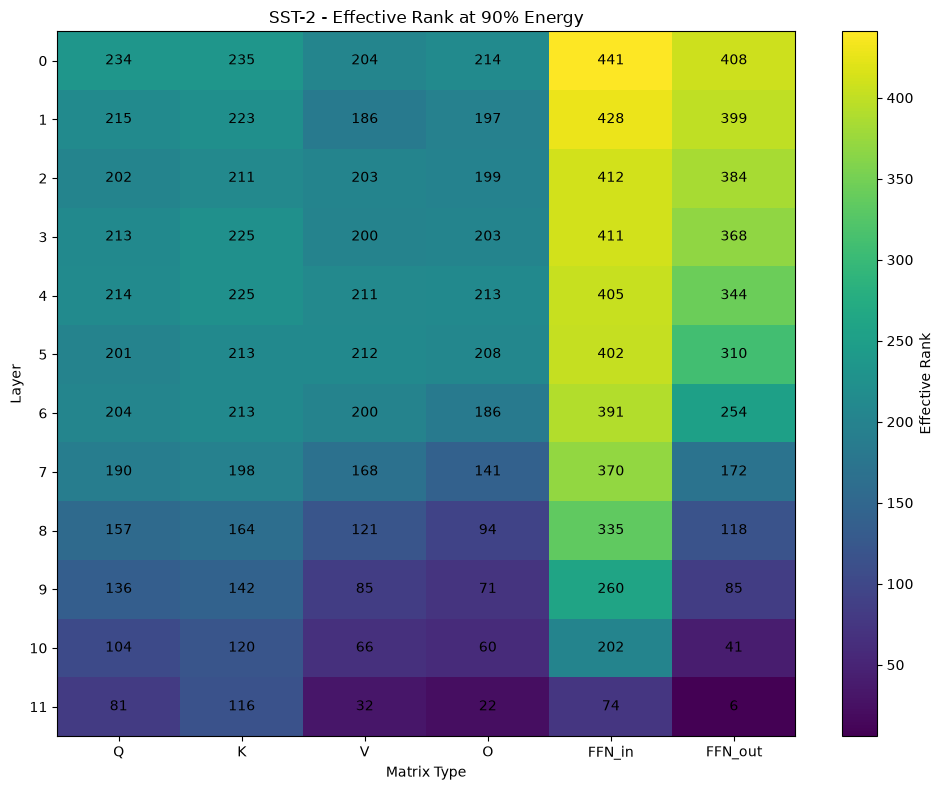

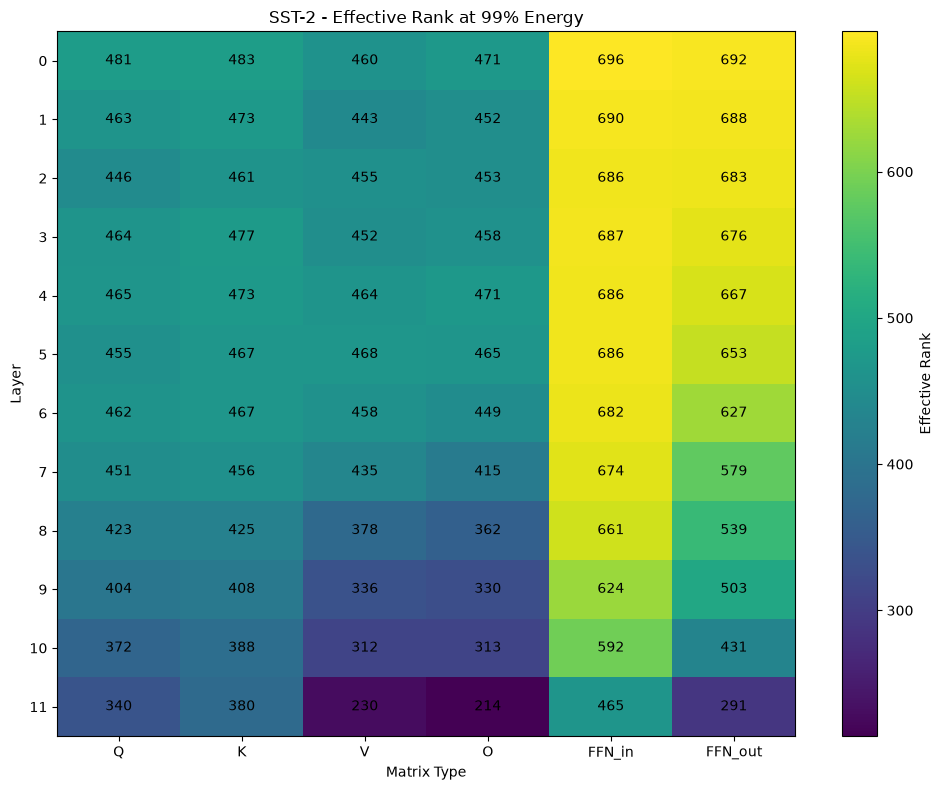

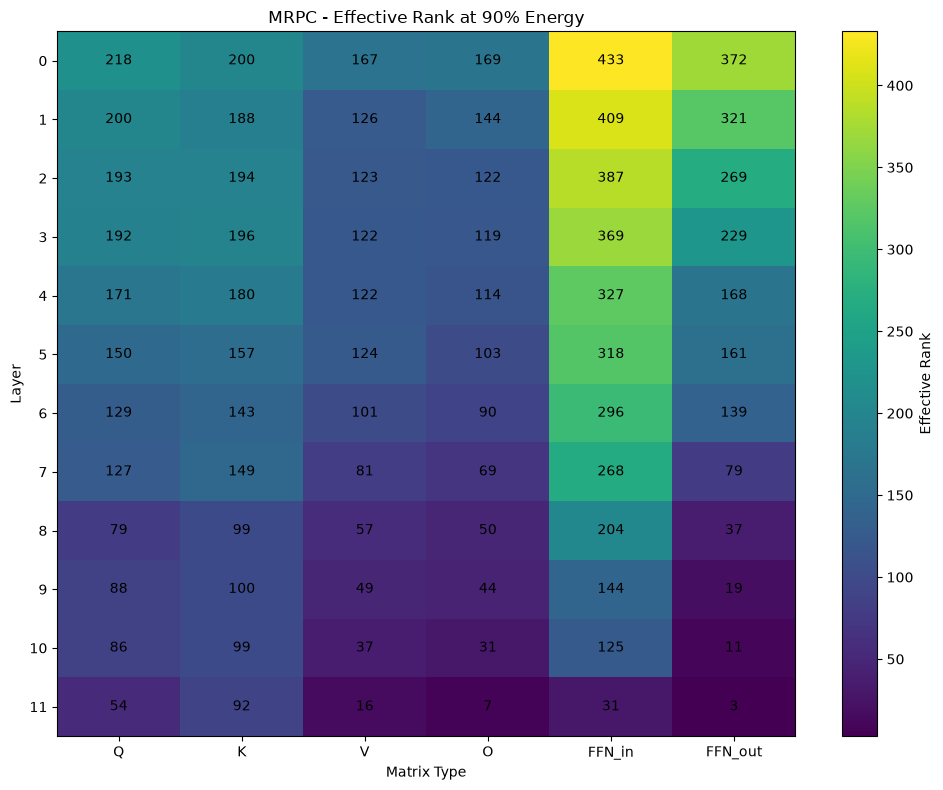

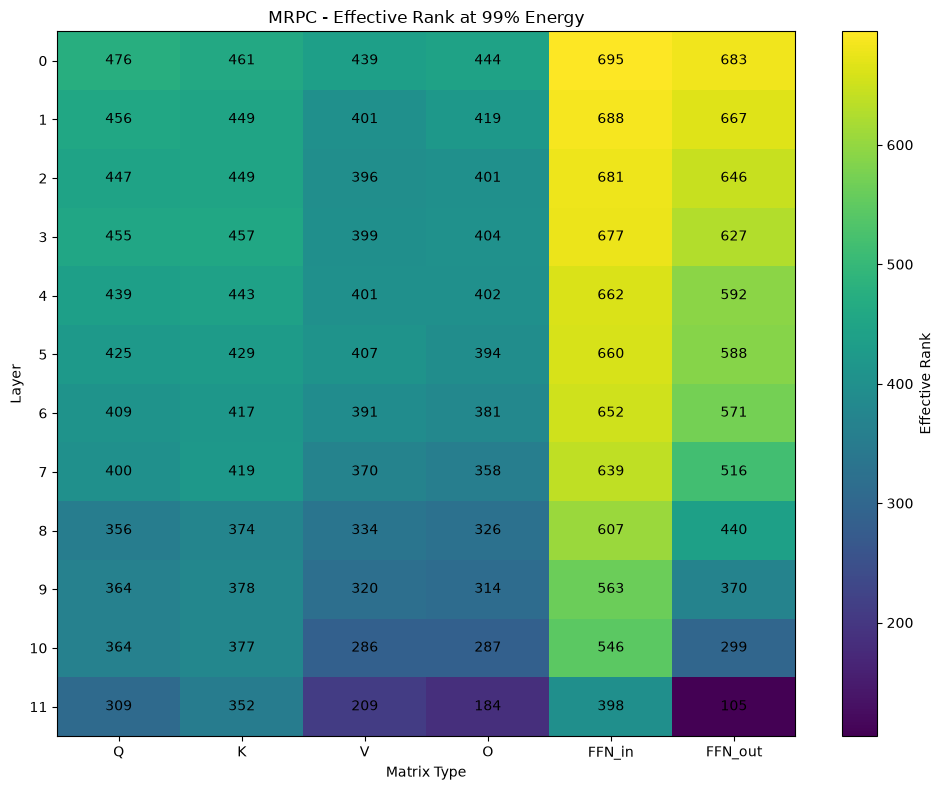

In [19]:
# =============================================================================
# HEATMAP — every layer x matrix-type cell at once (k90 and k99). BOTH tasks.
# =============================================================================
def plot_heatmap(rows, task):
    ## CODE HERE ##

    k90_values = np.zeros((12, 6))
    k99_values = np.zeros((12, 6))

    type_to_col = {"Q": 0, "K": 1, "V": 2, "O": 3, "FFN_in": 4, "FFN_out": 5}

    for row in rows:

        layer = row["layer"]
        col = type_to_col[row["mtype"]]

        k90_values[layer, col] = row["k90"]
        k99_values[layer, col] = row["k99"]
        
# For k90
    plt.figure(figsize=(10, 8))
    plt.imshow(k90_values, aspect="auto")

    plt.xticks(range(6), MATRIX_ORDER)
    plt.yticks(range(12), range(12))

    plt.xlabel("Matrix Type")
    plt.ylabel("Layer")
    plt.title(f"{task} - Effective Rank at 90% Energy")

    plt.colorbar(label="Effective Rank")

    for i in range(12):
        for j in range(6):
            plt.text(j, i, int(k90_values[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()

# For k99
    plt.figure(figsize=(10, 8))

    plt.imshow(k99_values, aspect="auto")

    plt.xticks(range(6), MATRIX_ORDER)
    plt.yticks(range(12), range(12))

    plt.xlabel("Matrix Type")
    plt.ylabel("Layer")
    plt.title(f"{task} - Effective Rank at 99% Energy")

    plt.colorbar(label="Effective Rank")

    for i in range(12):
        for j in range(6):
            plt.text(j, i, int(k99_values[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()       
        
            
for task, rows in ALL_TASKS:
    plot_heatmap(rows, task)

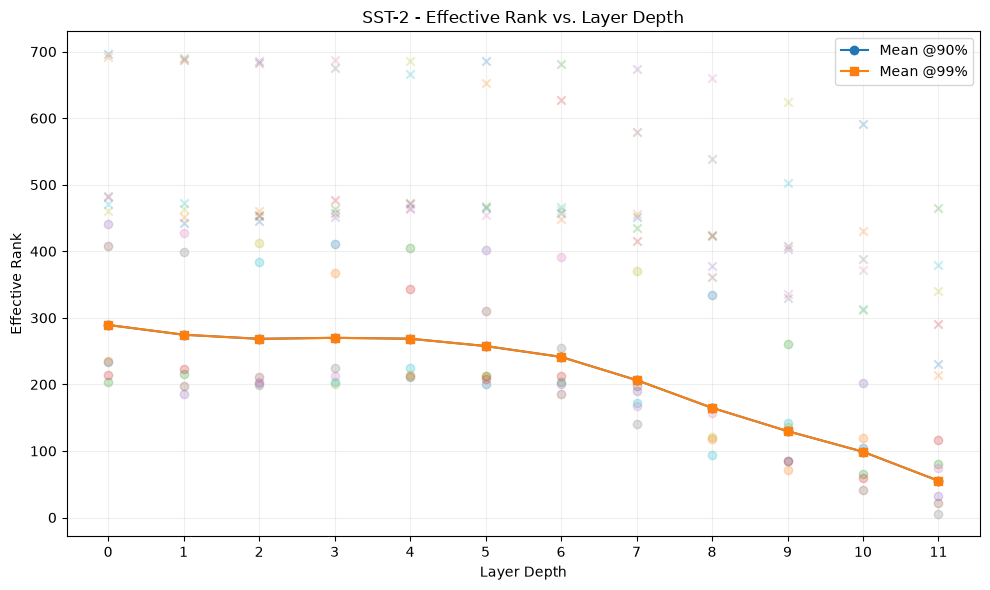

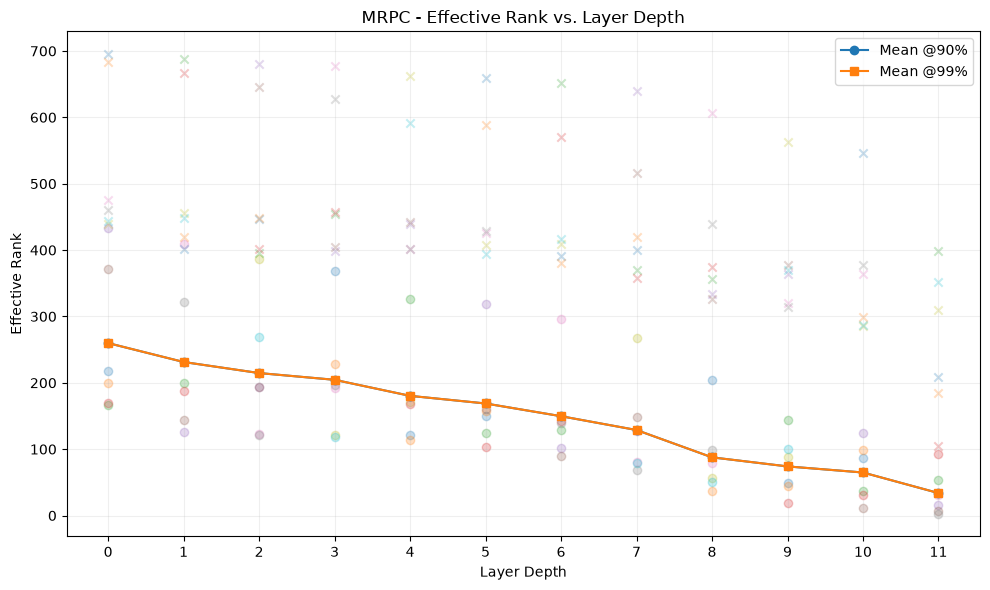

In [20]:
# =============================================================================
# PLOT 1 — effective rank vs. layer depth. Run for BOTH tasks.
#   Faint scatter = individual matrices; lines = mean (@90% and @99%).
# =============================================================================
def plot_rank_vs_depth(rows, task):

    d90, d99 = defaultdict(list), defaultdict(list)

    for row in rows:
        layer = row["layer"]

        d90[layer].append(row["k90"])
        d99[layer].append(row["k99"])

    layers = sorted(d90.keys())

    mean90 = []
    mean99 = []

    for layer in layers:
        mean90.append(np.mean(d90[layer]))
        mean99.append(np.mean(d99[layer]))

    plt.figure(figsize=(10, 6))

    for layer in layers:

        for rank in d90[layer]:
            plt.scatter(layer, rank, marker="o", alpha=0.25)

        for rank in d99[layer]:
            plt.scatter(layer, rank, marker="x", alpha=0.25)

    plt.plot(layers, mean90, marker="o", label="Mean @90%")
    plt.plot(layers, mean90, marker="s", label="Mean @99%")

    plt.xlabel("Layer Depth")
    plt.ylabel("Effective Rank")
    plt.title(f"{task} - Effective Rank vs. Layer Depth")

    plt.xticks(layers)
    plt.legend()
    plt.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()


for task, rows in ALL_TASKS:
    plot_rank_vs_depth(rows, task)

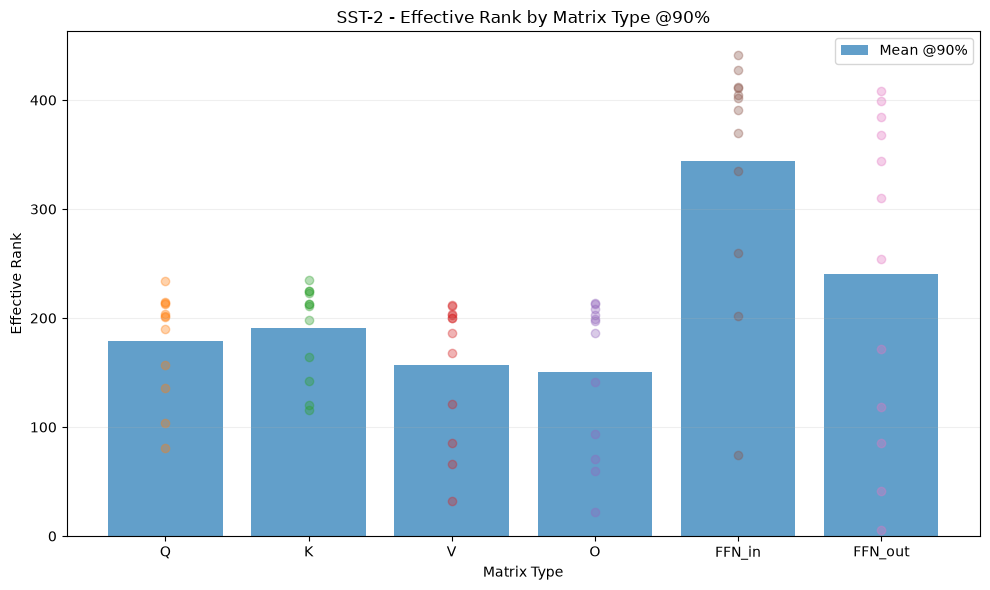

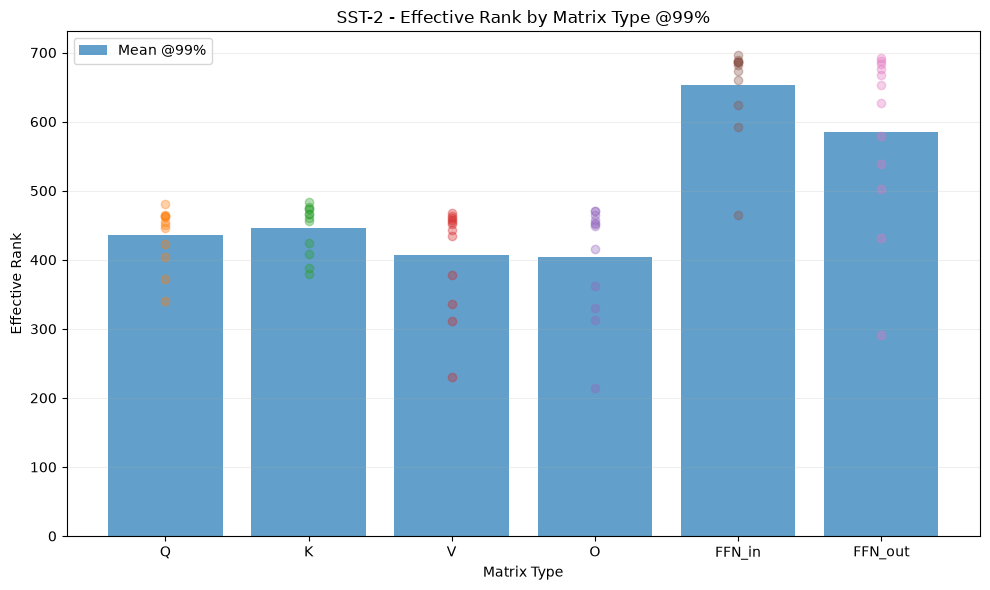

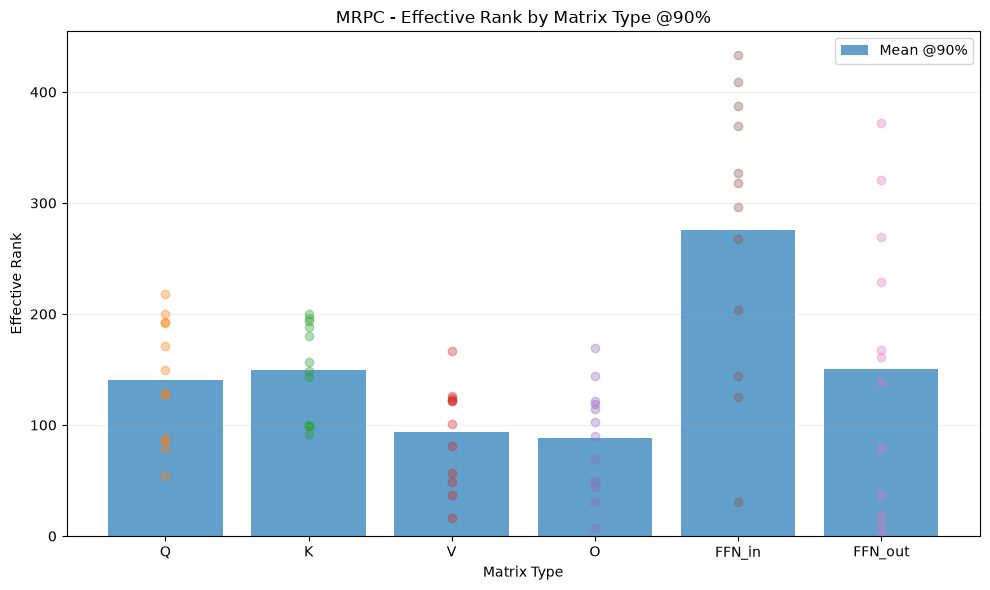

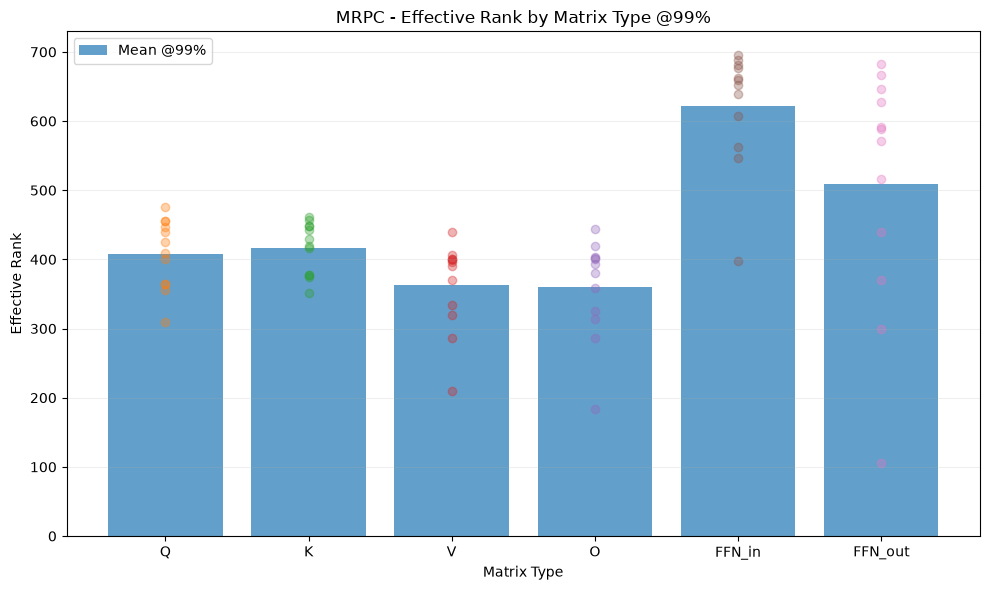

In [21]:
# =============================================================================
# PLOT 2 — effective rank vs. matrix type (Q/K/V/O/FFN). Run for BOTH tasks.
#   Bars = mean; scatter behind = every layer's matrix of that type.
# =============================================================================
def plot_rank_vs_type(rows, task):

    ranks90 = defaultdict(list)
    ranks99 = defaultdict(list)

    for row in rows:
        mtype = row["mtype"]

        ranks90[mtype].append(row["k90"])
        ranks99[mtype].append(row["k99"])

    x = np.arange(len(MATRIX_ORDER))

    mean90 = []
    mean99 = []

    for mtype in MATRIX_ORDER:
        mean90.append(np.mean(ranks90[mtype]))
        mean99.append(np.mean(ranks99[mtype]))

    plt.figure(figsize=(10, 6))

    plt.bar(x, mean90, alpha=0.7, label="Mean @90%")

    # Individual layer values
    for i, mtype in enumerate(MATRIX_ORDER):
        plt.scatter(np.full(len(ranks90[mtype]), i), ranks90[mtype], alpha=0.35)

    plt.xticks(x, MATRIX_ORDER)
    plt.xlabel("Matrix Type")
    plt.ylabel("Effective Rank")
    plt.title(f"{task} - Effective Rank by Matrix Type @90%")

    plt.legend()
    plt.grid(axis="y", alpha=0.2)

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    
    plt.bar(x, mean99, alpha=0.7, label="Mean @99%")

    for i, mtype in enumerate(MATRIX_ORDER):
        plt.scatter(np.full(len(ranks99[mtype]), i), ranks99[mtype], alpha=0.35)

    plt.xticks(x, MATRIX_ORDER)
    plt.xlabel("Matrix Type")
    plt.ylabel("Effective Rank")
    plt.title(f"{task} - Effective Rank by Matrix Type @99%")

    plt.legend()
    plt.grid(axis="y", alpha=0.2)

    plt.tight_layout()
    plt.show()


for task, rows in ALL_TASKS:
    plot_rank_vs_type(rows, task)

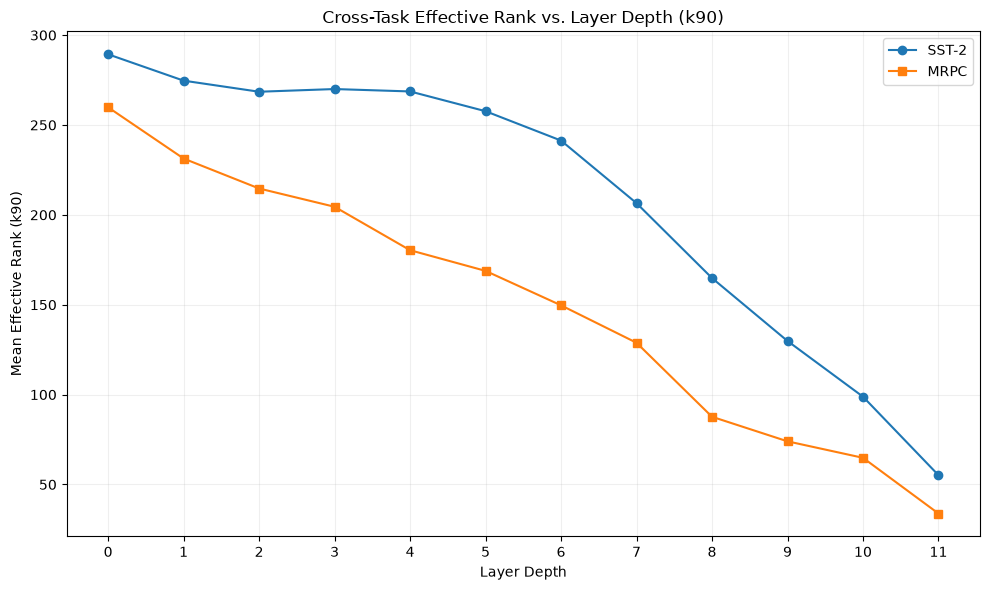

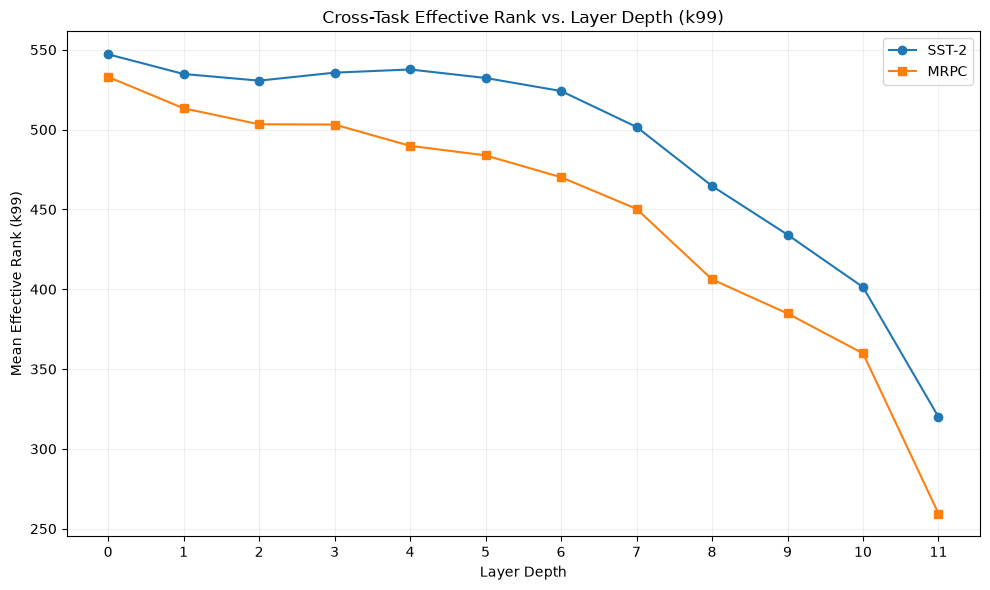

In [22]:
# =============================================================================
# CROSS-TASK 1 — overlaid depth profile (both tasks, one axis).
#   Curves track together -> rank is architectural (model). Curves diverge ->
#   rank is task-driven. This is the plot that answers "model vs task?".
# =============================================================================
def plot_depth_cross_task(rows_a, name_a, rows_b, name_b, key="k90"):

    depth_a = defaultdict(list)
    depth_b = defaultdict(list)

    for row in rows_a:
        depth_a[row["layer"]].append(row[key])

    for row in rows_b:
        depth_b[row["layer"]].append(row[key])

    layers = sorted(depth_a.keys())

    mean_a = []
    mean_b = []

    for layer in layers:
        mean_a.append(np.mean(depth_a[layer]))
        mean_b.append(np.mean(depth_b[layer]))

    plt.figure(figsize=(10, 6))

    plt.plot(layers, mean_a, marker="o", label=name_a)

    plt.plot(layers, mean_b, marker="s", label=name_b)

    plt.xlabel("Layer Depth")
    plt.ylabel(f"Mean Effective Rank ({key})")
    plt.title(
        f"Cross-Task Effective Rank vs. Layer Depth ({key})"
    )

    plt.xticks(layers)
    plt.legend()
    plt.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()


plot_depth_cross_task(rows_sst2, "SST-2", rows_mrpc, "MRPC")
plot_depth_cross_task(rows_sst2, "SST-2", rows_mrpc, "MRPC", key="k99")

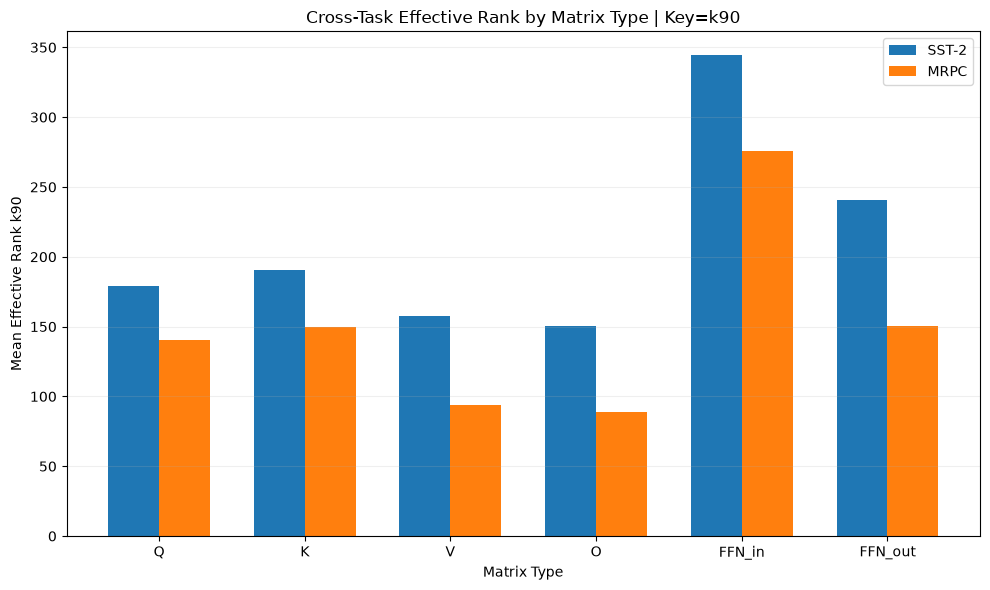

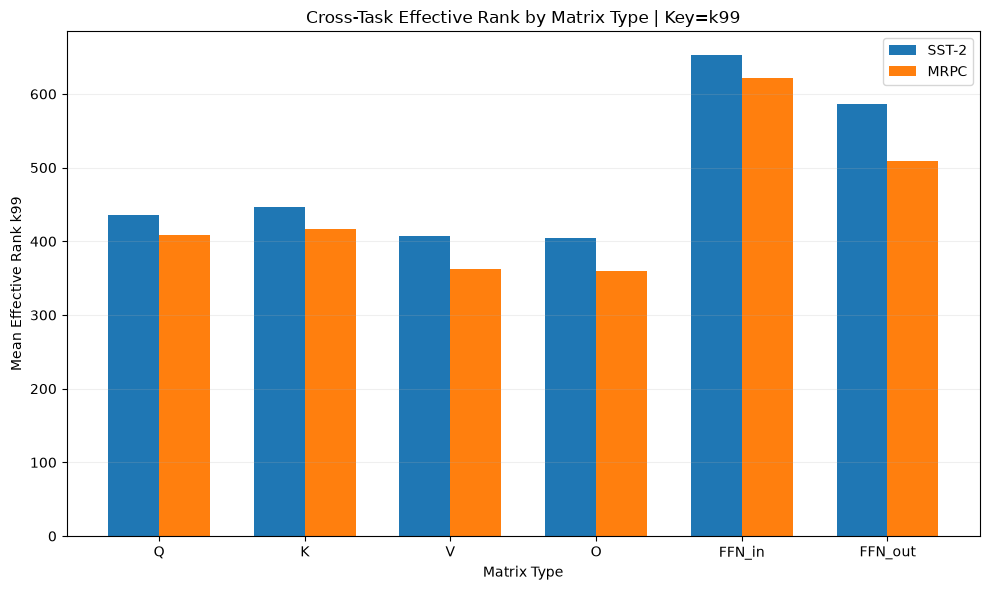

In [23]:
# =============================================================================
# CROSS-TASK 2 — rank by matrix type, both tasks side by side.
# =============================================================================
def plot_type_cross_task(rows_a, name_a, rows_b, name_b, key="k90"):

    ranks_a = defaultdict(list)
    ranks_b = defaultdict(list)

    for row in rows_a:
        ranks_a[row["mtype"]].append(row[key])

    for row in rows_b:
        ranks_b[row["mtype"]].append(row[key])

    mean_a = []
    mean_b = []

    for mtype in MATRIX_ORDER:
        mean_a.append(np.mean(ranks_a[mtype]))
        mean_b.append(np.mean(ranks_b[mtype]))

    x = np.arange(len(MATRIX_ORDER))
    width = 0.35

    plt.figure(figsize=(10, 6))
    plt.bar(x - width / 2, mean_a, width, label=name_a)
    plt.bar(x + width / 2, mean_b, width, label=name_b)

    plt.xticks(x, MATRIX_ORDER)
    plt.xlabel("Matrix Type")
    plt.ylabel(f"Mean Effective Rank {key}")
    plt.title(f"Cross-Task Effective Rank by Matrix Type | Key={key}")

    plt.legend()
    plt.grid(axis="y", alpha=0.2)

    plt.tight_layout()
    plt.show()


plot_type_cross_task(rows_sst2, "SST-2", rows_mrpc, "MRPC")
plot_type_cross_task(rows_sst2, "SST-2", rows_mrpc, "MRPC", key="k99")

In [24]:
# =============================================================================
# Aggregate by-type summary (means) — cite alongside Plot 2. BOTH tasks.
# =============================================================================
def summarize_by_type(rows, task):

    ranks90 = defaultdict(list)
    ranks99 = defaultdict(list)

    for row in rows:
        mtype = row["mtype"]

        ranks90[mtype].append(row["k90"])
        ranks99[mtype].append(row["k99"])

    print(f"\n{task} — MEAN EFFECTIVE RANK BY MATRIX TYPE")
    print("-" * 55)
    print(f"{'Matrix Type':<12} {'Mean @90%':>12} {'Mean @99%':>12}")
    print("-" * 55)

    for mtype in MATRIX_ORDER:

        mean90 = np.mean(ranks90[mtype])
        mean99 = np.mean(ranks99[mtype])

        print(
            f"{mtype:<12} "
            f"{mean90:>12.2f} "
            f"{mean99:>12.2f}"
        )


for task, rows in ALL_TASKS:
    summarize_by_type(rows, task)


SST-2 — MEAN EFFECTIVE RANK BY MATRIX TYPE
-------------------------------------------------------
Matrix Type     Mean @90%    Mean @99%
-------------------------------------------------------
Q                  179.25       435.50
K                  190.42       446.50
V                  157.33       407.58
O                  150.67       404.42
FFN_in             344.25       652.42
FFN_out            240.75       585.75

MRPC — MEAN EFFECTIVE RANK BY MATRIX TYPE
-------------------------------------------------------
Matrix Type     Mean @90%    Mean @99%
-------------------------------------------------------
Q                  140.58       408.33
K                  149.75       417.08
V                   93.75       362.75
O                   88.50       359.50
FFN_in             275.92       622.33
FFN_out            150.67       508.67


### <font color="red"><b>Reflection 1: </b></font>

**Q1 — Rank across layers & matrix types**

In [25]:
## ANSWER HERE ##
# - FFN-in have higher effective_rank across all 2 tasks for both k99 and k90
# - Generally FFN matrices shows higher effective ranks than QKVO
# - Deeper the layer more the difference ebtween ranks of FFN and QKVO is visible

**Q2 — Rank vs. depth & task consistency**

In [26]:
## ANSWER HERE ##

# - effective_rank is generally higher in lower layers so there is an inverse relation between layer number and plot_rank_vs_depth
# - This pattern is consistent in both tasks 
# - But it is also that, mrpc is showing lower ranks than sst2 consistently

# So overall this inverse relation between rank and layer-depth is hold by the architecture but tasks might define the absolute rank numbers


**Q3 — Implication for LoRA allocation**


In [27]:
## ANSWER HERE ##

# Since effective rank is higher in earlier layers, mainly for FFN. So this implies we should use higher LORA capacity in earlier layers and specially FFN Components

## <font color="blue"><b>Part-2: Rank Allocation and Layer-wise Adaptation Informed by Your Own Data. </b></font>

Using the effective-rank profile measured in **Part-1** (not a heuristic from any paper), investigate how the **amount, location, and type of adaptation** affect performance. All comparisons should use a **matched total trainable-parameter budget** wherever applicable.

---

### <font color="purple">Part 2.1: Implement LoRA — 1 mark</font>

Implement standard per-layer LoRA (`LoRALinear`).

---


### <font color="green">Part 2.2: How Much LoRA Capacity Is Needed? — 1 mark</font>

Train and compare the following LoRA configurations under a **matched total trainable-parameter budget**:

1. **Uniform-rank LoRA:** use the same rank $r$ across all selected layers (e.g., $r=8$ everywhere).

2. **Data-informed variable-rank LoRA:** assign a rank $r_\ell$ to each layer based on its measured effective rank from **Part-1**. Use a common rank scale (e.g., $r_\ell \in \{8,16,32,\ldots\}$) and adjust the allocation so that the total number of trainable parameters matches the uniform-rank baseline.

A higher-rank LoRA can represent lower-rank updates; therefore, comparing only the numerical values of $r$ is not a fair comparison. Explain why a **matched parameter budget** makes the comparison meaningful.

---

### <font color="purple">Part 2.3: Where Should Adaptation Capacity Be Placed? — 1 mark</font>

Apply adaptation to only a subset of layers while keeping the number of adapted layers and, where applicable, the **total trainable-parameter budget** comparable.

Compare:

1. **LoRA placement:** LoRA applied to earlier (bottom) layers versus later (top) layers.
2. **FFT placement:** Full fine-tuning (FFT) applied to earlier (bottom) layers versus later (top) layers.

Use these experiments to determine whether the **location of the adapted layers** affects task performance.

---

### <font color="green">Part 2.4: Can Different Layers Benefit from Different Adaptation Mechanisms? — 1 mark</font>

Construct a **hybrid LoRA + FFT** configuration in which one subset of layers is adapted using LoRA and another subset using full fine-tuning.

Compare:

1. **LoRA on the bottom layers + FFT on the top layers**
2. **FFT on the bottom layers + LoRA on the top layers**

Keep the **total number of trainable parameters comparable** across configurations.

Analyze whether combining low-rank and full-rank updates provides an advantage over using either adaptation method alone.

In [28]:
import torch.nn as nn

set_seed(SEED)

# --- shared hyperparameters --------------------------------------------------
LORA_EPOCHS = 4
LORA_LR     = 5e-4
FFT_LR      = 2e-5          # full-FT of a subset needs the small LR, like Part 1
LORA_ALPHA  = 16.0
R_UNIFORM   = 8
RMIN        = 1
ENERGY      = "k90"
TASK        = "sst2"

TARGET_TYPES = {"Q", "K", "V", "O", "FFN_in", "FFN_out"}
N_LAYERS     = 12
BOTTOM       = set(range(0, 6))     # layers 0-5
TOP          = set(range(6, 12))    # layers 6-11

In [29]:
# =============================================================================
# B1 — Standard LoRALinear.  y = Wx + (alpha/r)*(xA^T)B^T
#      base frozen; B=0 so adapter starts as a no-op.
# =============================================================================
class LoRALinear(nn.Module):
    ## CODE HERE ##
    def __init__(self, linear, r, alpha):
        super().__init__()

        self.linear = linear
        self.r = r
        self.alpha = alpha

        for p in self.linear.parameters():
            p.requires_grad = False

        self.A = nn.Parameter(torch.empty(r, linear.in_features, device=linear.weight.device))
        self.B = nn.Parameter(torch.zeros(linear.out_features, r, device=linear.weight.device))

        nn.init.kaiming_uniform_(self.A, a=5**0.5)
        self.scaling = alpha / r

    def forward(self, x):
        base = self.linear(x)
        lora = (x @ self.A.T) @ self.B.T
        return base + self.scaling * lora
    

# -----------------------------------------------------------------------------
# Target discovery, tagged with (layer, mtype) so it aligns with rows_sst2.
# `layers` optionally restricts the adapted layer range (used in B3/B4).
# -----------------------------------------------------------------------------
def find_targets(model, layers=None):

    out = []

    for name, module in model.named_modules():

        if not isinstance(module, nn.Linear):
            continue

        if "encoder.layer" not in name:
            continue

        parts = name.split(".")
        layer = int(parts[3])

        if layers is not None and layer not in layers:
            continue
        
        if name.endswith("attention.self.query"):
            mtype = "Q"
        elif name.endswith("attention.self.key"):
            mtype = "K"
        elif name.endswith("attention.self.value"):
            mtype = "V"
        elif name.endswith("attention.output.dense"):
            mtype = "O"
        elif name.endswith("intermediate.dense"):
            mtype = "FFN_in"
        elif name.endswith("output.dense"):
            mtype = "FFN_out"
        else:
            continue

        out.append((name, layer, mtype, module))

    return out


def target_cost(t):
    name, layer, mtype, lin = t
    return lin.in_features + lin.out_features        # params per unit rank

In [ ]:
# =============================================================================
# B2 — rank allocation
# =============================================================================
def uniform_ranks(targets):
    ## CODE HERE ##
    return {name: R_UNIFORM for name, _, _, _ in targets}

def variable_ranks(targets, rows, energy=ENERGY):
    """Rank proportional to measured effective rank, EXACT budget via
    largest-remainder. budget = R_UNIFORM * sum(cost)."""
    ## CODE HERE ##
    rank_lookup = {}

    for row in rows:
        rank_lookup[(row["layer"], row["mtype"])] = row[energy]

    names = []
    costs = []
    effective_ranks = []

    for name, layer, mtype, lin in targets:
        names.append(name)
        costs.append(target_cost((name, layer, mtype, lin)))
        effective_ranks.append(rank_lookup[(layer, mtype)])

    costs = np.asarray(costs, dtype=np.int64)
    effective_ranks = np.asarray(effective_ranks, dtype=np.float64)

    budget = R_UNIFORM * costs.sum()

    weights = effective_ranks / effective_ranks.sum()
    target_params = budget * weights
    continuous_r = np.maximum(target_params / costs, RMIN)

    r = np.floor(continuous_r).astype(int)
    r = np.maximum(r, RMIN)

    remainders = continuous_r - np.floor(continuous_r)

    current_budget = int(np.sum(r * costs))
    remaining = budget - current_budget

    while remaining > 0:
        candidates = [i for i in range(len(r)) if costs[i] <= remaining]

        if not candidates:
            break
        
        best = max(candidates, key=lambda i: remainders[i])
        r[best] += 1
        remaining -= int(costs[best])

    current_budget = int(np.sum(r * costs))
    difference = budget - current_budget

    if difference != 0:
        best_r = None
        best_error = float("inf")

        for i in range(len(r)):
            if r[i] <= RMIN:
                continue

            new_r = r.copy()
            new_r[i] -= 1

            new_budget = int(np.sum(new_r * costs))
            needed = budget - new_budget

            for j in range(len(r)):
                if needed >= 0 and needed % costs[j] == 0:
                    increase = needed // costs[j]

                    if increase > 0:
                        candidate_r = new_r.copy()
                        candidate_r[j] += increase

                        error = np.sum((candidate_r - continuous_r) ** 2)

                        if error < best_error:
                            best_error = error
                            best_r = candidate_r

        if best_r is None:
            for i in range(len(r)):
                if r[i] <= RMIN:
                    continue

                for k in range(i + 1, len(r)):
                    if r[k] <= RMIN:
                        continue

                    new_r = r.copy()
                    new_r[i] -= 1
                    new_r[k] -= 1

                    new_budget = int(np.sum(new_r * costs))
                    needed = budget - new_budget

                    for j in range(len(r)):
                        if needed >= 0 and needed % costs[j] == 0:
                            increase = needed // costs[j]

                            if increase > 0:
                                candidate_r = new_r.copy()
                                candidate_r[j] += increase

                                error = np.sum((candidate_r - continuous_r) ** 2)

                                if error < best_error:
                                    best_error = error
                                    best_r = candidate_r

        if best_r is not None:
            r = best_r

    final_budget = int(np.sum(r * costs))

    assert final_budget == budget, (
        f"Budget mismatch: {final_budget} != {budget}"
    )

    return dict(zip(names, r.tolist()))

def apply_lora(model, rank_map):
    ## CODE HERE ##
    for name, module in list(model.named_modules()):

        if name not in rank_map:
            continue

        parts = name.split(".")
        parent = model

        for part in parts[:-1]:
            parent = getattr(parent, part)

        child_name = parts[-1]
        linear = getattr(parent, child_name)

        lora = LoRALinear(linear, r=rank_map[name], alpha=LORA_ALPHA).to(linear.weight.device)

        setattr(parent, child_name, lora)

    return model

def apply_lora_layers(model, layers, r=R_UNIFORM):
    """Attach uniform-r LoRA only to the given layer set (used in B3/B4)."""
    ## CODE HERE ##
    targets = find_targets(model, layers=layers)
    rank_map = uniform_ranks(targets)
    apply_lora(model, rank_map)
    return model

In [31]:
# =============================================================================
# B3/B4 — full fine-tuning of a LAYER SUBSET.
#   Freeze everything, then unfreeze only the encoder layers in `layers`.
#   The classifier head is always trainable (otherwise nothing can learn the
#   label mapping); this is noted in the writeup.
# =============================================================================
def freeze_all(model):
    for p in model.parameters():
        p.requires_grad = False

def unfreeze_layers(model, layers):
    ## CODE HERE ##
    for name, p in model.named_parameters():
        if "encoder.layer" not in name:
            continue

        layer = int(name.split(".")[3])

        if layer in layers:
            p.requires_grad = True

def trainable_count(model):
    ## CODE HERE ##
    count = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return count

def lora_param_count(model):
   ## CODE HERE ##
   count = sum(p.numel() for name, p in model.named_parameters() if p.requires_grad and (".A" in name or ".B" in name))
   
   return count

# =============================================================================
# Unified training loop (works for LoRA, FFT-subset, and hybrid).
# =============================================================================
def train_model(model, train_loader, val_loader, tag, lr):
    ## CODE HERE ##
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr
    )

    total_steps = LORA_EPOCHS * len(train_loader)

    scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer,
        start_factor=1.0,
        end_factor=0.0,
        total_iters=total_steps
    )

    for epoch in range(LORA_EPOCHS):
        model.train()
        running_loss = 0.0

        for step, (input_ids, attention_mask, labels) in enumerate(train_loader, start=1):
            input_ids = input_ids.to(DEVICE)
            attention_mask = attention_mask.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

            loss = outputs.loss
            loss.backward()

            optimizer.step()
            scheduler.step()

            running_loss += loss.item()
            
            if step%100==0:
                print(f"{tag} | epoch {epoch + 1}/{LORA_EPOCHS} | step {step}/{len(train_loader)} | loss {running_loss / 100:.4f}")
            
        print(f"{tag} | epoch {epoch + 1}/{LORA_EPOCHS} completed")

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for input_ids, attention_mask, labels in val_loader:
            input_ids = input_ids.to(DEVICE)
            attention_mask = attention_mask.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            predictions = torch.argmax(outputs.logits, dim=-1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total

    print(f"{tag} | validation accuracy: {accuracy:.4f}")

    return accuracy

def fresh_model():
    set_seed(SEED)
    return AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2).to(DEVICE)

In [32]:
from datasets import load_from_disk

mrpc = load_from_disk("Dataset/mrpc")
sst2 = load_from_disk("Dataset/sst2")

print(mrpc)
print(sst2)

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})
DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 61398
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 3411
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 3412
    })
})


In [33]:
# =============================================================================
# RUN
# =============================================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
train_loader, val_loader = build_loaders(TASK, tokenizer)
results = {}   # tag -> (val_acc, trainable_params)

In [ ]:
# ---------------------------------------------------------------------------
# B2(i)  uniform r=8 (all layers)
# ---------------------------------------------------------------------------
print("\n########## B2: uniform r=8 ##########")
## CODE HERE ##

model = fresh_model()

targets = find_targets(model)
rank_map = uniform_ranks(targets)

apply_lora(model, rank_map)

print("Trainable parameters:", trainable_count(model))
print("LoRA parameters:", lora_param_count(model))

acc_uniform = train_model(model, train_loader, val_loader, tag="uniform_r8", lr=LORA_LR)

results["uniform_r8"] = (acc_uniform, trainable_count(model))


########## B2: uniform r=8 ##########


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7352.98it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

Trainable parameters: 25793282
LoRA parameters: 1327104
uniform_r8 | epoch 1/4 | step 100/960 | loss 0.3345
uniform_r8 | epoch 1/4 | step 200/960 | loss 0.5685
uniform_r8 | epoch 1/4 | step 300/960 | loss 0.7730
uniform_r8 | epoch 1/4 | step 400/960 | loss 0.9743
uniform_r8 | epoch 1/4 | step 500/960 | loss 1.1778
uniform_r8 | epoch 1/4 | step 600/960 | loss 1.3648
uniform_r8 | epoch 1/4 | step 700/960 | loss 1.5393
uniform_r8 | epoch 1/4 | step 800/960 | loss 1.7074
uniform_r8 | epoch 1/4 | step 900/960 | loss 1.8571
uniform_r8 | epoch 1/4 completed
uniform_r8 | epoch 2/4 | step 100/960 | loss 0.0849
uniform_r8 | epoch 2/4 | step 200/960 | loss 0.1655
uniform_r8 | epoch 2/4 | step 300/960 | loss 0.2524
uniform_r8 | epoch 2/4 | step 400/960 | loss 0.3460
uniform_r8 | epoch 2/4 | step 500/960 | loss 0.4398
uniform_r8 | epoch 2/4 | step 600/960 | loss 0.5265
uniform_r8 | epoch 2/4 | step 700/960 | loss 0.6265
uniform_r8 | epoch 2/4 | step 800/960 | loss 0.7226
uniform_r8 | epoch 2/4 | st

In [ ]:
# ---------------------------------------------------------------------------
# B2(ii) data-informed variable rank (all layers, SAME budget)
# ---------------------------------------------------------------------------
print("\n########## B2: data-informed variable rank ##########")
## CODE HERE ##

model = fresh_model()

targets = find_targets(model)

rank_map = variable_ranks(targets, rows_sst2, energy=ENERGY)

print("Variable rank allocation:")
for name, r in rank_map.items():
    print(f"{name}: r={r}")

apply_lora(model, rank_map)

print("Trainable parameters:", trainable_count(model))
print("LoRA parameters:", lora_param_count(model))

acc_variable = train_model(model, train_loader, val_loader, tag="variable_rank", lr=LORA_LR)

results["variable_r"] = (acc_variable, trainable_count(model))


########## B2: data-informed variable rank ##########


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7145.99it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

Variable rank allocation:
bert.encoder.layer.0.attention.self.query: r=13
bert.encoder.layer.0.attention.self.key: r=13
bert.encoder.layer.0.attention.self.value: r=11
bert.encoder.layer.0.attention.output.dense: r=12
bert.encoder.layer.0.intermediate.dense: r=9
bert.encoder.layer.0.output.dense: r=9
bert.encoder.layer.1.attention.self.query: r=12
bert.encoder.layer.1.attention.self.key: r=12
bert.encoder.layer.1.attention.self.value: r=10
bert.encoder.layer.1.attention.output.dense: r=11
bert.encoder.layer.1.intermediate.dense: r=9
bert.encoder.layer.1.output.dense: r=9
bert.encoder.layer.2.attention.self.query: r=11
bert.encoder.layer.2.attention.self.key: r=12
bert.encoder.layer.2.attention.self.value: r=11
bert.encoder.layer.2.attention.output.dense: r=11
bert.encoder.layer.2.intermediate.dense: r=9
bert.encoder.layer.2.output.dense: r=8
bert.encoder.layer.3.attention.self.query: r=12
bert.encoder.layer.3.attention.self.key: r=12
bert.encoder.layer.3.attention.self.value: r=11
bert

In [51]:
# ---------------------------------------------------------------------------
# B3  PLACEMENT — LoRA bottom vs top  (same #layers, same r -> matched budget)
# ---------------------------------------------------------------------------
print("\n########## B3: LoRA placement (bottom vs top) ##########")
## CODE HERE ##

import gc

model_bottom = fresh_model()
freeze_all(model_bottom)
apply_lora_layers(model_bottom, BOTTOM, r=R_UNIFORM)

for p in model_bottom.classifier.parameters():
    p.requires_grad = True

print("Bottom LoRA layers:", sorted(BOTTOM))
print("Trainable parameters:", trainable_count(model_bottom))
print("LoRA parameters:", lora_param_count(model_bottom))

acc_lora_bottom = train_model(model_bottom, train_loader, val_loader, tag="LoRA_bottom", lr=LORA_LR)

results["lora_bottom"] = (acc_lora_bottom, trainable_count(model_bottom))

del model_bottom
gc.collect()
torch.cuda.empty_cache()

model_top = fresh_model()
freeze_all(model_top)
apply_lora_layers(model_top, TOP, r=R_UNIFORM)

for p in model_top.classifier.parameters():
    p.requires_grad = True

print("Top LoRA layers:", sorted(TOP))
print("Trainable parameters:", trainable_count(model_top))
print("LoRA parameters:", lora_param_count(model_top))

acc_lora_top = train_model(model_top, train_loader, val_loader, tag="LoRA_top", lr=LORA_LR)

results["lora_top"] = (acc_lora_top, trainable_count(model_top))

del model_top
gc.collect()
torch.cuda.empty_cache()


########## B3: LoRA placement (bottom vs top) ##########


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7192.80it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

Bottom LoRA layers: [0, 1, 2, 3, 4, 5]
Trainable parameters: 665090
LoRA parameters: 663552
LoRA_bottom | epoch 1/4 | step 100/960 | loss 0.4885
LoRA_bottom | epoch 1/4 | step 200/960 | loss 0.8063
LoRA_bottom | epoch 1/4 | step 300/960 | loss 1.0630
LoRA_bottom | epoch 1/4 | step 400/960 | loss 1.3233
LoRA_bottom | epoch 1/4 | step 500/960 | loss 1.5816
LoRA_bottom | epoch 1/4 | step 600/960 | loss 1.8184
LoRA_bottom | epoch 1/4 | step 700/960 | loss 2.0543
LoRA_bottom | epoch 1/4 | step 800/960 | loss 2.2762
LoRA_bottom | epoch 1/4 | step 900/960 | loss 2.4771
LoRA_bottom | epoch 1/4 completed
LoRA_bottom | epoch 2/4 | step 100/960 | loss 0.1659
LoRA_bottom | epoch 2/4 | step 200/960 | loss 0.3312
LoRA_bottom | epoch 2/4 | step 300/960 | loss 0.4933
LoRA_bottom | epoch 2/4 | step 400/960 | loss 0.6653
LoRA_bottom | epoch 2/4 | step 500/960 | loss 0.8322
LoRA_bottom | epoch 2/4 | step 600/960 | loss 0.9841
LoRA_bottom | epoch 2/4 | step 700/960 | loss 1.1465
LoRA_bottom | epoch 2/4 | 

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7422.95it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

Top LoRA layers: [6, 7, 8, 9, 10, 11]
Trainable parameters: 665090
LoRA parameters: 663552
LoRA_top | epoch 1/4 | step 100/960 | loss 0.4176
LoRA_top | epoch 1/4 | step 200/960 | loss 0.7234
LoRA_top | epoch 1/4 | step 300/960 | loss 0.9954
LoRA_top | epoch 1/4 | step 400/960 | loss 1.2621
LoRA_top | epoch 1/4 | step 500/960 | loss 1.5343
LoRA_top | epoch 1/4 | step 600/960 | loss 1.7900
LoRA_top | epoch 1/4 | step 700/960 | loss 2.0416
LoRA_top | epoch 1/4 | step 800/960 | loss 2.2782
LoRA_top | epoch 1/4 | step 900/960 | loss 2.4986
LoRA_top | epoch 1/4 completed
LoRA_top | epoch 2/4 | step 100/960 | loss 0.2025
LoRA_top | epoch 2/4 | step 200/960 | loss 0.3996
LoRA_top | epoch 2/4 | step 300/960 | loss 0.5940
LoRA_top | epoch 2/4 | step 400/960 | loss 0.7877
LoRA_top | epoch 2/4 | step 500/960 | loss 0.9705
LoRA_top | epoch 2/4 | step 600/960 | loss 1.1536
LoRA_top | epoch 2/4 | step 700/960 | loss 1.3434
LoRA_top | epoch 2/4 | step 800/960 | loss 1.5273
LoRA_top | epoch 2/4 | step 

In [57]:
results

{'uniform_r8': (0.9478, 25793282),
 'variable_r': (0.949, 25793282),
 'lora_bottom': (0.9475, 665090),
 'lora_top': (0.9472, 665090)}

In [67]:
# ---------------------------------------------------------------------------
# B3  PLACEMENT — FFT bottom vs top  (same #layers -> matched budget)
#     NB: full-FT of 6 layers >> any LoRA budget; counts are reported, not
#     equalized to the LoRA runs (see writeup note).
# ---------------------------------------------------------------------------
print("\n########## B3: FFT placement (bottom vs top) ##########")
## CODE HERE ##

model_bottom = fresh_model()
freeze_all(model_bottom)
unfreeze_layers(model_bottom, BOTTOM)

for p in model_bottom.classifier.parameters():
    p.requires_grad = True

print("Bottom FFT layers:", sorted(BOTTOM))
print("Trainable parameters:", trainable_count(model_bottom))

acc_fft_bottom = train_model(model_bottom, train_loader, val_loader, tag="FFT_bottom", lr=FFT_LR)

results['fft_bottom'] = (acc_fft_bottom, trainable_count(model_bottom))

del model_bottom
gc.collect()
torch.cuda.empty_cache()

model_top = fresh_model()
freeze_all(model_top)
unfreeze_layers(model_top, TOP)

for p in model_top.classifier.parameters():
    p.requires_grad = True

print("Top FFT layers:", sorted(TOP))
print("Trainable parameters:", trainable_count(model_top))

acc_fft_top = train_model(model_top, train_loader, val_loader, tag="FFT_top", lr=FFT_LR)

results['fft_top'] = (acc_fft_top, trainable_count(model_top))

del model_top
gc.collect()
torch.cuda.empty_cache()


########## B3: FFT placement (bottom vs top) ##########


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7231.81it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

Bottom FFT layers: [0, 1, 2, 3, 4, 5]
Trainable parameters: 42528770
FFT_bottom | epoch 1/4 | step 100/960 | loss 0.6184
FFT_bottom | epoch 1/4 | step 200/960 | loss 1.0118
FFT_bottom | epoch 1/4 | step 300/960 | loss 1.3120
FFT_bottom | epoch 1/4 | step 400/960 | loss 1.5917
FFT_bottom | epoch 1/4 | step 500/960 | loss 1.8627
FFT_bottom | epoch 1/4 | step 600/960 | loss 2.1161
FFT_bottom | epoch 1/4 | step 700/960 | loss 2.3572
FFT_bottom | epoch 1/4 | step 800/960 | loss 2.5877
FFT_bottom | epoch 1/4 | step 900/960 | loss 2.7909
FFT_bottom | epoch 1/4 completed
FFT_bottom | epoch 2/4 | step 100/960 | loss 0.1707
FFT_bottom | epoch 2/4 | step 200/960 | loss 0.3368
FFT_bottom | epoch 2/4 | step 300/960 | loss 0.4983
FFT_bottom | epoch 2/4 | step 400/960 | loss 0.6702
FFT_bottom | epoch 2/4 | step 500/960 | loss 0.8309
FFT_bottom | epoch 2/4 | step 600/960 | loss 0.9874
FFT_bottom | epoch 2/4 | step 700/960 | loss 1.1532
FFT_bottom | epoch 2/4 | step 800/960 | loss 1.3142
FFT_bottom | e

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7288.07it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

Top FFT layers: [6, 7, 8, 9, 10, 11]
Trainable parameters: 42528770
FFT_top | epoch 1/4 | step 100/960 | loss 0.4551
FFT_top | epoch 1/4 | step 200/960 | loss 0.7674
FFT_top | epoch 1/4 | step 300/960 | loss 1.0537
FFT_top | epoch 1/4 | step 400/960 | loss 1.3246
FFT_top | epoch 1/4 | step 500/960 | loss 1.6008
FFT_top | epoch 1/4 | step 600/960 | loss 1.8593
FFT_top | epoch 1/4 | step 700/960 | loss 2.1090
FFT_top | epoch 1/4 | step 800/960 | loss 2.3513
FFT_top | epoch 1/4 | step 900/960 | loss 2.5684
FFT_top | epoch 1/4 completed
FFT_top | epoch 2/4 | step 100/960 | loss 0.1940
FFT_top | epoch 2/4 | step 200/960 | loss 0.3823
FFT_top | epoch 2/4 | step 300/960 | loss 0.5689
FFT_top | epoch 2/4 | step 400/960 | loss 0.7556
FFT_top | epoch 2/4 | step 500/960 | loss 0.9341
FFT_top | epoch 2/4 | step 600/960 | loss 1.1142
FFT_top | epoch 2/4 | step 700/960 | loss 1.3032
FFT_top | epoch 2/4 | step 800/960 | loss 1.4874
FFT_top | epoch 2/4 | step 900/960 | loss 1.6628
FFT_top | epoch 2/4 

In [69]:
results

{'uniform_r8': (0.9478, 25793282),
 'variable_r': (0.949, 25793282),
 'lora_bottom': (0.9475, 665090),
 'lora_top': (0.9472, 665090),
 'fft_bottom': (0.9489885664028144, 42528770),
 'fft_top': (0.9451773673409557, 42528770)}

In [70]:
# ---------------------------------------------------------------------------
# B4  HYBRID — mix LoRA and FFT on disjoint layer subsets.
#     Config 1: LoRA on bottom + FFT on top
#     Config 2: FFT on bottom + LoRA on top
#     Both use one LR; LoRA params sit at LORA_LR-scale updates, base at FFT
#     scale -> we use a single small compromise LR to keep it simple & stable.
# ---------------------------------------------------------------------------
HYBRID_LR = 1e-4   # compromise: base weights tolerate this; LoRA still learns

print("\n########## B4: hybrid LoRA-bottom + FFT-top ##########")
## CODE HERE ##

model_bottom_lora = fresh_model()
freeze_all(model_bottom_lora)
apply_lora_layers(model_bottom_lora, BOTTOM, r=R_UNIFORM)
unfreeze_layers(model_bottom_lora, TOP)

for p in model_bottom_lora.classifier.parameters():
    p.requires_grad = True

print("LoRA bottom layers:", sorted(BOTTOM))
print("FFT top layers:", sorted(TOP))
print("Trainable parameters:", trainable_count(model_bottom_lora))
print("LoRA parameters:", lora_param_count(model_bottom_lora))

acc_hybrid_lora_bottom = train_model(model_bottom_lora, train_loader, val_loader, tag="Hybrid_LoRA_bottom_FFT_top", lr=HYBRID_LR)

results["hybrid_loraB_fftT"] = (acc_hybrid_lora_bottom, trainable_count(model_bottom_lora))

del model_bottom_lora
gc.collect()
torch.cuda.empty_cache()



print("\n########## B4: hybrid FFT-bottom + LoRA-top ##########")
## CODE HERE ##

model_top_lora = fresh_model()
freeze_all(model_top_lora)
apply_lora_layers(model_top_lora, TOP, r=R_UNIFORM)
unfreeze_layers(model_top_lora, BOTTOM)

for p in model_top_lora.classifier.parameters():
    p.requires_grad = True

print("FFT bottom layers:", sorted(BOTTOM))
print("LoRA top layers:", sorted(TOP))
print("Trainable parameters:", trainable_count(model_top_lora))
print("LoRA parameters:", lora_param_count(model_top_lora))

acc_hybrid_fft_bottom = train_model(model_top_lora, train_loader, val_loader, tag="Hybrid_FFT_bottom_LoRA_top", lr=HYBRID_LR)

results["hybrid_fftB_loraT"] = (acc_hybrid_fft_bottom, trainable_count(model_top_lora))

del model_top_lora
gc.collect()
torch.cuda.empty_cache()


########## B4: hybrid LoRA-bottom + FFT-top ##########


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7263.78it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

LoRA bottom layers: [0, 1, 2, 3, 4, 5]
FFT top layers: [6, 7, 8, 9, 10, 11]
Trainable parameters: 43192322
LoRA parameters: 663552
Hybrid_LoRA_bottom_FFT_top | epoch 1/4 | step 100/960 | loss 0.3950
Hybrid_LoRA_bottom_FFT_top | epoch 1/4 | step 200/960 | loss 0.6709
Hybrid_LoRA_bottom_FFT_top | epoch 1/4 | step 300/960 | loss 0.9000
Hybrid_LoRA_bottom_FFT_top | epoch 1/4 | step 400/960 | loss 1.1276
Hybrid_LoRA_bottom_FFT_top | epoch 1/4 | step 500/960 | loss 1.3560
Hybrid_LoRA_bottom_FFT_top | epoch 1/4 | step 600/960 | loss 1.5698
Hybrid_LoRA_bottom_FFT_top | epoch 1/4 | step 700/960 | loss 1.7730
Hybrid_LoRA_bottom_FFT_top | epoch 1/4 | step 800/960 | loss 1.9675
Hybrid_LoRA_bottom_FFT_top | epoch 1/4 | step 900/960 | loss 2.1295
Hybrid_LoRA_bottom_FFT_top | epoch 1/4 completed
Hybrid_LoRA_bottom_FFT_top | epoch 2/4 | step 100/960 | loss 0.1265
Hybrid_LoRA_bottom_FFT_top | epoch 2/4 | step 200/960 | loss 0.2511
Hybrid_LoRA_bottom_FFT_top | epoch 2/4 | step 300/960 | loss 0.3747
Hybr

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6531.80it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

FFT bottom layers: [0, 1, 2, 3, 4, 5]
LoRA top layers: [6, 7, 8, 9, 10, 11]
Trainable parameters: 43192322
LoRA parameters: 663552
Hybrid_FFT_bottom_LoRA_top | epoch 1/4 | step 100/960 | loss 0.4410
Hybrid_FFT_bottom_LoRA_top | epoch 1/4 | step 200/960 | loss 0.7243
Hybrid_FFT_bottom_LoRA_top | epoch 1/4 | step 300/960 | loss 0.9477
Hybrid_FFT_bottom_LoRA_top | epoch 1/4 | step 400/960 | loss 1.1667
Hybrid_FFT_bottom_LoRA_top | epoch 1/4 | step 500/960 | loss 1.3935
Hybrid_FFT_bottom_LoRA_top | epoch 1/4 | step 600/960 | loss 1.5915
Hybrid_FFT_bottom_LoRA_top | epoch 1/4 | step 700/960 | loss 1.7890
Hybrid_FFT_bottom_LoRA_top | epoch 1/4 | step 800/960 | loss 1.9713
Hybrid_FFT_bottom_LoRA_top | epoch 1/4 | step 900/960 | loss 2.1330
Hybrid_FFT_bottom_LoRA_top | epoch 1/4 completed
Hybrid_FFT_bottom_LoRA_top | epoch 2/4 | step 100/960 | loss 0.1022
Hybrid_FFT_bottom_LoRA_top | epoch 2/4 | step 200/960 | loss 0.2084
Hybrid_FFT_bottom_LoRA_top | epoch 2/4 | step 300/960 | loss 0.3173
Hybr

In [71]:
results

{'uniform_r8': (0.9478, 25793282),
 'variable_r': (0.949, 25793282),
 'lora_bottom': (0.9475, 665090),
 'lora_top': (0.9472, 665090),
 'fft_bottom': (0.9489885664028144, 42528770),
 'fft_top': (0.9451773673409557, 42528770),
 'hybrid_loraB_fftT': (0.9486953972442099, 43192322),
 'hybrid_fftB_loraT': (0.9492817355614189, 43192322)}

In [72]:
# =============================================================================
# SUMMARY — everything Reflection 2 needs, in one table.
# =============================================================================
print("\n==================== Part 2 SUMMARY ====================")
print(f"{'config':<26}{'val_acc':>10}{'trainable_params':>20}")
for tag, (acc, p) in results.items():
    print(f"{tag:<26}{acc:>10.4f}{p:>20,}")

print("\n--- Reflection 2 deltas ---")
print(f"variable - uniform         : {results['variable_r'][0]-results['uniform_r8'][0]:+.4f}")
print(f"LoRA  top - bottom         : {results['lora_top'][0]-results['lora_bottom'][0]:+.4f}")
print(f"FFT   top - bottom         : {results['fft_top'][0]-results['fft_bottom'][0]:+.4f}")
best_hybrid = max(results['hybrid_loraB_fftT'][0], results['hybrid_fftB_loraT'][0])
best_single = max(results['uniform_r8'][0], results['fft_top'][0], results['fft_bottom'][0])
print(f"best hybrid - best single  : {best_hybrid-best_single:+.4f}")


==================== Part 2 SUMMARY ====================
config                       val_acc    trainable_params
uniform_r8                    0.9478          25,793,282
variable_r                    0.9490          25,793,282
lora_bottom                   0.9475             665,090
lora_top                      0.9472             665,090
fft_bottom                    0.9490          42,528,770
fft_top                       0.9452          42,528,770
hybrid_loraB_fftT             0.9487          43,192,322
hybrid_fftB_loraT             0.9493          43,192,322

--- Reflection 2 deltas ---
variable - uniform         : +0.0012
LoRA  top - bottom         : -0.0003
FFT   top - bottom         : -0.0038
best hybrid - best single  : +0.0003


### <font color="red"><b>Reflection 2: </b></font>


**Q1 — Data-informed variable rank vs. uniform rank (matched budget)**


In [73]:
## ANSWER HERE ##

# Clearly there is a +0.0012 acc increase in data informed variable rank lora in comparison to uniform ranking. 

# So clearly data informed variable rank lora setup works better

**Q2 — Does location of adaptation matter? (LoRA vs FFT, bottom vs top)**


In [75]:
## ANSWER HERE ##

# In our expperiment the differece between [LoRA  top - bottom : -0.0003] is very very small suggesting that the loccation of adaptors is very negligible. 
# However i must point out that it can be possible that this small difference is due to the small setting of experiment


# At the same time [FFT top - bottom : -0.0038] shows greater difference compared to LORA setting. 

# Location effect is larger in FFT than LORA



**Q3 — Does hybrid LoRA + FFT beat either alone?**


In [78]:
## ANSWER HERE ##
a = """
Best hybrid
-----------------------------------------------------------
hybrid_fftB_loraT             0.9493          43,192,322


LORA ALONE: 
-----------------------------------------------------------
uniform_r8                    0.9478          25,793,282

FFT ALONE: 
-----------------------------------------------------------
fft_bottom                    0.9490          42,528,770
fft_top                       0.9452          42,528,770

"""

# Clearly there is an advantage in hybrid experiment but a very small one

## <font color="blue"><b>Part-3: LoRA for the Embedding Layer (non-standard part of standard LoRA).</b></font>

Every standard LoRA implementation covers `nn.Linear`. Almost none cover the embedding layer, because an embedding lookup is a **row-selection** operation, not a dense matrix multiply.

---

### <font color="green">Part 3.1: Derive LoRA for the Embedding Layer — 2 marks</font>

Derive, from first principles, the correct low-rank decomposition for an embedding matrix

$$
E \in \mathbb{R}^{V \times d}
$$

where $V$ is the vocabulary size and $d$ is the embedding dimension.

Your derivation must show that:

- The adapter consists of **two small matrices** whose product has the same shape as $E$.
- The forward pass **only gathers rows corresponding to the token IDs present in the batch**.
- The full $V \times d$ correction matrix must **not** be materialized during every forward pass.
- Clearly identify which matrix plays the role of **A** and which plays the role of **B**.
- Explain why this is **not simply the transpose of the Linear-layer case**.

---

In [ ]:
import torch.nn as nn
set_seed(SEED)

C.1 — DERIVATION (from first principles)

Linear layer: $h = Wx$, $W \in \mathbb{R}^{out \times in}$. LoRA:
$W \mathrel{+}= (\alpha/r)BA$, with $A:(r \times in)$ and $B:(out \times r)$.

- The **input dimension is contracted** by a matrix multiplication.
- Nothing is gathered.
- $A$ is on the input side and $B$ is on the output side.

Embedding layer: a lookup. $E \in \mathbb{R}^{V \times d}$, where for token ID $t$, the output is the **row $E[t]$** of length $d$.

- The vocabulary axis $V$ is **indexed (row-selection)**, not contracted.
- There is no matrix multiplication against the vocabulary dimension.

Low-rank correction with the **same shape as $E$**:

$$
\Delta E = A_e B_e
$$

where

$$
A_e:(V \times r), \qquad B_e:(r \times d)
$$

and therefore

$$
(V \times r)(r \times d) = (V \times d),
$$

which matches the shape of $E$.

**Caveat on "two small matrices":** $B_e:(r \times d)$ is small, but $A_e:(V \times r)$ is vocabulary-sized (approximately $30522 \times 8$). This is inherent: a per-row correction over the whole vocabulary cannot avoid a $V$-sized factor. The embedding adapter is "small" in its rank-$r$ structure, but its parameter cost is dominated by $V \times r$.

Memory-efficient forward:

$$
(E + \Delta E)[t]
= E[t] + (A_eB_e)[t]
= E[t] + A_e[t]B_e.
$$

Only row $t$ of $A_e$ is gathered, followed by a small $(r \times d)$ matrix multiplication. The full $V \times d$ correction is **never materialized**; only rows corresponding to tokens in the batch are used.

Which is $A$ and which is $B$:

- $A_e:(V \times r)$ is the factor **indexed by token ID** (the gathered factor).
- $B_e:(r \times d)$ is the factor **contracted into the embedding dimension**.

Initialization:

- $A_e$ is randomly initialized using Kaiming initialization.
- $B_e$ is initialized to zero.
- Therefore, $\Delta E = 0$ at initialization, giving a no-op clean start.
- The token-indexed factor is randomized so that gradients can flow into $B_e$ first.

Why this is **not simply the transpose of the Linear case**:

In a Linear layer, the contracted input dimension is represented by $A:(r \times in)$, and both factors participate directly in a matrix multiplication.

Simply transposing this layout for an embedding would place the large vocabulary dimension $V$ on a factor that must be contracted, potentially requiring a $V$-sized matrix multiplication or full $V \times d$ materialization.

In an embedding layer, $V$ is **never contracted**; it is **indexed**. Therefore, the large vocabulary dimension must remain on the gathered factor:

$$
A_e:(V \times r).
$$

This allows the implementation to gather $A_e[t]$ efficiently. The factor placement is determined by **indexed vs. contracted dimensions**, so the embedding case is not merely a transpose of the Linear-layer case.

**Note on Part A:** Part A deliberately excluded the embedding layer ("Embeddings → Part C"), so its intrinsic rank was not measured there. Part C.3b computes the embedding intrinsic rank using the same full-fine-tuning delta methodology as Part A.

---

### <font color="purple">Part 3.2: Implement and Verify `LoRAEmbedding` — 1 mark</font>

Implement the derived decomposition as a `LoRAEmbedding` module.

Verify correctness using a **merge-equivalence unit test**.

---

### <font color="green">Part 3.3: Apply LoRA to the Input Embedding — 1 mark</font>

Apply LoRA to the **input embedding layer in addition to the attention projections**.

Test whether adapting the embedding:

- Helps performance
- Hurts performance
- Has no significant effect

Report the effective-rank measurement for the **embedding weight delta** specifically, as in Part-1.

Compare its intrinsic rank with the attention-layer updates and discuss whether the embedding has a **higher or lower intrinsic rank** than the attention layers.
____

In [80]:
# =============================================================================
# C.2 — LoRAEmbedding module
# =============================================================================
class LoRAEmbedding(nn.Module):
    """LoRA adapter for nn.Embedding. Base frozen; dE = A_e @ B_e,
    A_e:(V x r) indexed by token id, B_e:(r x d) contracted into dim d.
    Forward gathers only rows for tokens present in the batch."""
    ## CODE HERE ##
    
    def __init__(self, embedding, r, alpha):
        super().__init__()

        self.embedding = embedding
        self.r = r
        self.alpha = alpha
        self.scaling = alpha / r

        for p in self.embedding.parameters():
            p.requires_grad = False

        V = embedding.num_embeddings
        d = embedding.embedding_dim

        self.A_e = nn.Parameter(torch.empty(V, r, device=embedding.weight.device))
        self.B = nn.Parameter(torch.zeros(r, d, device=embedding.weight.device))

        nn.init.kaiming_uniform_(self.A_e, a=5**0.5)

    def forward(self, input_ids):
        base = self.embedding(input_ids)

        delta = nn.functional.embedding(input_ids, self.A_e)
        delta = delta @ self.B

        return base + self.scaling * delta
    
    def merged_weight(self):
        return self.embedding.weight + self.scaling * (self.A_e @ self.B)

In [81]:
# =============================================================================
# C.2b — merge-equivalence unit test
# =============================================================================
def test_merge_equivalence():
    torch.manual_seed(0)
    V, d, r = 100, 16, 4
    base = nn.Embedding(V, d)
    lora = LoRAEmbedding(base, r=r, alpha=16.0)
    with torch.no_grad():
        lora.B.copy_(torch.randn(r, d))                # nonzero correction
    tokens = torch.randint(0, V, (3, 7))               # batch with repeats
    out_gather = lora(tokens)
    merged = nn.Embedding(V, d)
    with torch.no_grad():
        merged.weight.copy_(lora.merged_weight())
    out_merged = merged(tokens)
    max_err = (out_gather - out_merged).abs().max().item()
    print(f"[merge test] max |gather - merged| = {max_err:.2e}")
    assert max_err < 1e-5, "merge equivalence FAILED"
    print("[merge test] PASS")

test_merge_equivalence()

[merge test] max |gather - merged| = 0.00e+00
[merge test] PASS


In [82]:
# =============================================================================
# C.3 — Controlled experiment: attention-only vs attention + embedding.
#   Attention/FFN adapters IDENTICAL in both arms (uniform r=8, same seed); the
#   ONLY difference is whether the input embedding is additionally adapted, so
#   the delta isolates the embedding's marginal effect. The +embedding arm has
#   extra params by construction -- that delta is reported, not hidden.
# =============================================================================
EMB_RANK = 8

def ab_params(model):
    return sum(p.numel() for n, p in model.named_parameters()
               if p.requires_grad and (".A" in n or ".B" in n))

def build_attention_only(seed):
    ## CODE HERE ##
    set_seed(seed)

    model = fresh_model()
    freeze_all(model)

    targets = [t for t in find_targets(model) if t[2] in {"Q", "K", "V", "O"}]

    rank_map = uniform_ranks(targets)
    apply_lora(model, rank_map)

    for p in model.classifier.parameters():
        p.requires_grad = True

    return model

def build_with_embedding(seed):
    ## CODE HERE ##
    set_seed(seed)

    model = fresh_model()
    freeze_all(model)

    targets = [t for t in find_targets(model) if t[2] in {"Q", "K", "V", "O"}]

    rank_map = uniform_ranks(targets)
    apply_lora(model, rank_map)

    embedding = model.bert.embeddings.word_embeddings

    model.bert.embeddings.word_embeddings = LoRAEmbedding(embedding, r=EMB_RANK, alpha=LORA_ALPHA)

    for p in model.classifier.parameters():
        p.requires_grad = True

    return model

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
train_loader, val_loader = build_loaders("sst2", tokenizer)

model_attn = build_attention_only(SEED)
p_attn = ab_params(model_attn)
print("attention-only  A/B params:", p_attn)
acc_attn = train_model(model_attn, train_loader, val_loader, "attn-only", LORA_LR)

model_emb = build_with_embedding(SEED)
p_emb = ab_params(model_emb)
print("attn+embedding  A/B params:", p_emb, f"(+{p_emb - p_attn} from embedding adapter)")
acc_emb = train_model(model_emb, train_loader, val_loader, "attn+emb", LORA_LR)

print("\n============= Part C.3 result (embedding effect) =============")
print(f"attention-only    val_acc = {acc_attn:.4f}   (A/B params {p_attn})")
print(f"attn + embedding  val_acc = {acc_emb:.4f}   (A/B params {p_emb})")
print(f"delta (emb - attn)        = {acc_emb - acc_attn:+.4f}")
print("-> help / hurt / nothing? Interpret against the +param cost above.")

# =============================================================================
# C.3b — effective rank of the EMBEDDING weight delta (same method as Part A),
#   WITH diagnostics so the number is interpretable rather than taken at face
#   value. dE = E_finetuned - E_pretrained from the Part A full-FT checkpoint.
#
#   Why diagnostics: on SST-2 only tokens SEEN in training get gradient, so most
#   vocab rows have dE ~ 0. Zero rows add no singular directions -- the effective
#   rank is really the rank of the ACTIVE-token subspace. We report the active-
#   row fraction and ||dE||_F so the rank is framed correctly, and note that k99
#   is sensitive to a diffuse optimizer/weight-decay noise floor.
# =============================================================================
def embedding_effective_rank():
    ## CODE HERE ##

    pretrained = fresh_model()

    ft_model = AutoModelForSequenceClassification.from_pretrained(
        "Output/ft_sst2",
        num_labels=2
    ).to(DEVICE)

    E_pre = pretrained.bert.embeddings.word_embeddings.weight.detach().float()
    E_ft = ft_model.bert.embeddings.word_embeddings.weight.detach().float()

    delta = E_ft - E_pre

    row_norms = torch.linalg.vector_norm(delta, dim=1)
    active = row_norms > 1e-12

    active_delta = delta[active]

    active_fraction = active.float().mean().item()
    fro_norm = torch.linalg.norm(active_delta).item()

    k90 = effective_rank(active_delta, 0.90)
    k99 = effective_rank(active_delta, 0.99)

    print("\n============= Embedding effective rank =============")
    print(f"Embedding shape: {tuple(delta.shape)}")
    print(f"Active rows: {active.sum().item()} / {delta.shape[0]}")
    print(f"Active-row fraction: {active_fraction:.4f}")
    print(f"||dE||_F: {fro_norm:.6f}")
    print(f"k90: {k90}")
    print(f"k99: {k99}")

    return {
        "k90": k90,
        "k99": k99,
        "active_rows": int(active.sum().item()),
        "active_fraction": active_fraction,
        "fro_norm": fro_norm
    }


embedding_effective_rank()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7119.42it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

attention-only  A/B params: 589824
attn-only | epoch 1/4 | step 100/960 | loss 0.4301
attn-only | epoch 1/4 | step 200/960 | loss 0.7254
attn-only | epoch 1/4 | step 300/960 | loss 0.9729
attn-only | epoch 1/4 | step 400/960 | loss 1.2202
attn-only | epoch 1/4 | step 500/960 | loss 1.4689
attn-only | epoch 1/4 | step 600/960 | loss 1.7000
attn-only | epoch 1/4 | step 700/960 | loss 1.9227
attn-only | epoch 1/4 | step 800/960 | loss 2.1407
attn-only | epoch 1/4 | step 900/960 | loss 2.3449
attn-only | epoch 1/4 completed
attn-only | epoch 2/4 | step 100/960 | loss 0.1752
attn-only | epoch 2/4 | step 200/960 | loss 0.3477
attn-only | epoch 2/4 | step 300/960 | loss 0.5220
attn-only | epoch 2/4 | step 400/960 | loss 0.6958
attn-only | epoch 2/4 | step 500/960 | loss 0.8684
attn-only | epoch 2/4 | step 600/960 | loss 1.0300
attn-only | epoch 2/4 | step 700/960 | loss 1.2020
attn-only | epoch 2/4 | step 800/960 | loss 1.3682
attn-only | epoch 2/4 | step 900/960 | loss 1.5280
attn-only | epo

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7258.73it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

attn+embedding  A/B params: 840144 (+250320 from embedding adapter)
attn+emb | epoch 1/4 | step 100/960 | loss 0.4256
attn+emb | epoch 1/4 | step 200/960 | loss 0.7081
attn+emb | epoch 1/4 | step 300/960 | loss 0.9596
attn+emb | epoch 1/4 | step 400/960 | loss 1.2084
attn+emb | epoch 1/4 | step 500/960 | loss 1.4560
attn+emb | epoch 1/4 | step 600/960 | loss 1.6858
attn+emb | epoch 1/4 | step 700/960 | loss 1.9148
attn+emb | epoch 1/4 | step 800/960 | loss 2.1351
attn+emb | epoch 1/4 | step 900/960 | loss 2.3298
attn+emb | epoch 1/4 completed
attn+emb | epoch 2/4 | step 100/960 | loss 0.1747
attn+emb | epoch 2/4 | step 200/960 | loss 0.3431
attn+emb | epoch 2/4 | step 300/960 | loss 0.5087
attn+emb | epoch 2/4 | step 400/960 | loss 0.6827
attn+emb | epoch 2/4 | step 500/960 | loss 0.8457
attn+emb | epoch 2/4 | step 600/960 | loss 1.0108
attn+emb | epoch 2/4 | step 700/960 | loss 1.1811
attn+emb | epoch 2/4 | step 800/960 | loss 1.3323
attn+emb | epoch 2/4 | step 900/960 | loss 1.4931
a

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7314.51it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi


============= Embedding effective rank =============
Embedding shape: (30522, 768)
Active rows: 30522 / 30522
Active-row fraction: 1.0000
||dE||_F: 1.611387
k90: 547
k99: 738


{'k90': 547,
 'k99': 738,
 'active_rows': 30522,
 'active_fraction': 0.9999999403953552,
 'fro_norm': 1.611386775970459}

| Setup                 | Validation accuracy | A/B parameters |
| --------------------- | ------------------: | -------------: |
| Attention-only        |              0.9493 |        589,824 |
| Attention + Embedding |              0.9507 |        840,144 |
| Difference            |         **+0.0015** |       +250,320 |

`Yes. adding embedding adapters helped with the experiment with an increase in validation loss by 0.0015`

============= Embedding effective rank =============
- Embedding shape: (30522, 768)
- Active rows: 30522 / 30522
- Active-row fraction: 1.0000
- ||dE||_F: 1.611387
- k90: 547
- k99: 738


In [ ]:
##------End-----##